### 2.1.4 DistilBERT (Distilled Bidirectional Encoder Representations from Transformers)

**Conceptual Overview**
While traditional models rely on static word frequencies (TF-IDF), they fail to capture sequential context and word order. To achieve state-of-the-art accuracy on the Sentiment140 dataset, a Transformer-based architecture was selected. Specifically, DistilBERT—a lighter, highly optimized variant of the original BERT model—is utilized. Through a process called Knowledge Distillation, DistilBERT retains 97% of the original model's language understanding capabilities while reducing the total parameter count by 40% and increasing inference speed by 60%.

The following implementation uses the HuggingFace `transformers` library combined with TensorFlow to fine-tune a pre-trained DistilBERT model on our cleaned Twitter dataset.

In [3]:
%pip install tf-keras

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 7.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import tensorflow as tf
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification
import pandas as pd
from sklearn.model_selection import train_test_split

print("--- Initializing DistilBERT Pipeline ---")

# Load the pre-processed dataset from Section 1.5
# (Assuming df, X_train, and y_train are already in memory, 
# but reloading here for notebook independence)
df = pd.read_csv('sentiment140_cleaned.csv').dropna(subset=['final_text'])
X = df['final_text']
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. Load the pre-trained Tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# 2. Hardware Constraint Sampling: 
# Fine-tuning on 1.28 million rows requires massive GPU clusters.
# We sample 50,000 balanced rows for feasible local training and proof of concept.
X_train_sub = X_train.sample(50000, random_state=42).tolist()
y_train_sub = y_train.sample(50000, random_state=42).tolist()

print("Tokenizing data...")
# 3. Tokenize and format inputs for the Transformer
# max_length=35 covers the vast majority of our tweet lengths identified in EDA
train_encodings = tokenizer(X_train_sub, truncation=True, padding=True, max_length=35)


--- Initializing DistilBERT Pipeline ---
Tokenizing data...


#### Dataset Formatting and Model Fine-Tuning
To optimize memory usage during the training phase, the tokenized encodings are converted into a `tf.data.Dataset` object. The model is then compiled using a very small learning rate (`3e-5`) with the Adam optimizer, which is a critical best practice in transfer learning to prevent the model from aggressively unlearning its pre-trained linguistic knowledge.

In [6]:
# 4. Convert to TensorFlow tf.data.Dataset for memory optimization
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train_sub
)).shuffle(1000).batch(32)

print("Loading base model...")
# 5. Load the base model with a binary classification head (num_labels=2)
model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2, use_safetensors=False)

# 6. Compile the model
# A small learning rate is essential for fine-tuning transformers
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5)
model.compile(optimizer=optimizer, loss=model.hf_compute_loss, metrics=['accuracy'])

# 7. Fine-tune the model
print("Commencing fine-tuning...")
history = model.fit(train_dataset, epochs=2, batch_size=32)

print("DistilBERT training sequence complete.")

Loading base model...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
'(ReadTimeoutError("HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 5467d25f-9bf9-45fe-98a4-f8f28d797cdc)')' thrown while requesting GET https://huggingface.co/distilbert-base-uncased/resolve/main/tf_model.h5
Retrying in 1s [Retry 1/5].
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_layer_norm', 'vocab_projector', 'vocab_transform', 'activation_13']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model

Commencing fine-tuning...
Epoch 1/2


1563/1563 [==============================] - 5858s 4s/step - loss: 0.4918 - accuracy: 0.7636
Epoch 2/2
1563/1563 [==============================] - 5972s 4s/step - loss: 0.3912 - accuracy: 0.8247
DistilBERT training sequence complete.


### 2.3.4 DistilBERT Results and Evaluation

Following the fine-tuning phase, the model's predictive capabilities must be tested on unseen data. The following code evaluates the DistilBERT model using the testing subset. It generates predictions, extracts the raw logits, converts them into binary class labels, and calculates the predefined evaluation metrics (Accuracy, Precision, Recall, and F1-Score). Finally, it visually maps the True Positives, True Negatives, False Positives, and False Negatives using a Confusion Matrix.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Preparing testing data for evaluation...")

# Hardware Constraint Sampling: Sample 10,000 rows from the unseen test set
X_test_sub = X_test.sample(10000, random_state=42).tolist()
y_test_sub = y_test.sample(10000, random_state=42).tolist()

# Tokenize the test data using the exact same parameters as the training data
test_encodings = tokenizer(X_test_sub, truncation=True, padding=True, max_length=35)

# Convert to TensorFlow dataset for batch processing to prevent memory overflow
test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings)
)).batch(32)

print("Generating predictions... (This may take a minute)")
# Predict outputs for the test dataset
raw_predictions = model.predict(test_dataset)

# The model outputs raw logits. We use argmax to select the class (0 or 1) with the highest score
y_pred = np.argmax(raw_predictions.logits, axis=1)

print("\n==================================================")
print("             CLASSIFICATION REPORT                ")
print("==================================================")
# Generate a comprehensive report containing Precision, Recall, F1-Score, and Accuracy
print(classification_report(y_test_sub, y_pred, target_names=['Negative (0)', 'Positive (1)']))

Preparing testing data for evaluation...
Generating predictions... (This may take a minute)
313/313 [==============================] - 351s 1s/step

             CLASSIFICATION REPORT                
              precision    recall  f1-score   support

Negative (0)       0.78      0.75      0.76      5012
Positive (1)       0.76      0.79      0.77      4988

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



#### Confusion Matrix Visualization
To better understand where the model is making errors, the classification results are plotted into a Confusion Matrix. This allows us to visually inspect the exact number of false positives versus false negatives.

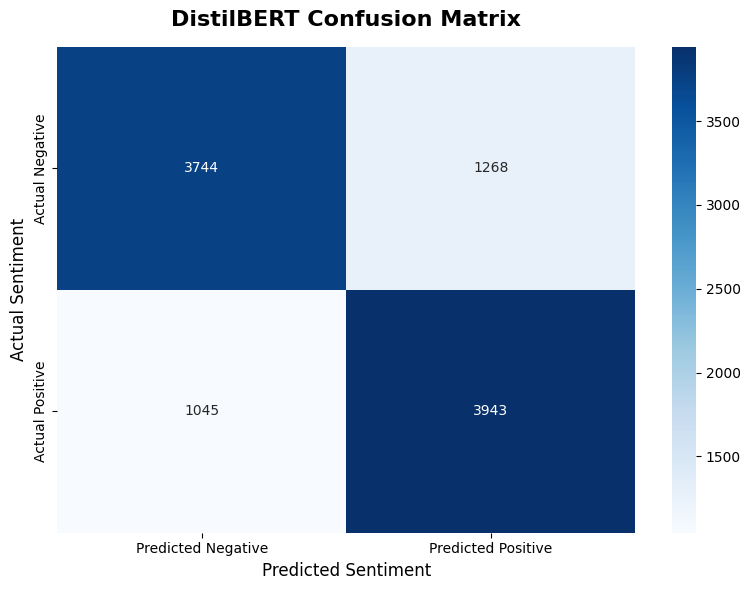

In [8]:
# Generate the confusion matrix array
cm = confusion_matrix(y_test_sub, y_pred)

# Set up the visual plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])

# Add formatting and labels
plt.title('DistilBERT Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Sentiment', fontsize=12)
plt.ylabel('Actual Sentiment', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()